<a href="https://colab.research.google.com/github/yasmeentalata/prediction-achat-en-ligne/blob/main/prediction_achat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

url = (
    "https://archive.ics.uci.edu/static/public/468/"
    "online%2Bshoppers%2Bpurchasing%2Bintention%2Bdataset.zip"
)

df = pd.read_csv(url, compression="zip")
print(df.shape)

print("Nombre de lignes et de colonnes :", df.shape)
display(df.head())
print("\nAchats et non-achats :")
print(df["Revenue"].value_counts())

(12330, 18)
Nombre de lignes et de colonnes : (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Achats et non-achats :
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [15]:
print("Taux d'achat :", round(df["Revenue"].mean() * 100, 1), "%")
print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print("Types des colonnes :")
print(df.dtypes)

Taux d'achat : 15.5 %
Valeurs manquantes par colonne :
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
Types des colonnes :
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
Oper

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

colonnes = ["Administrative", "Informational", "ProductRelated",
            "BounceRates", "ExitRates", "SpecialDay"]

X = df[colonnes]       # Informations utilisées pour prédire
y = df["Revenue"]      # Résultat à prédire : achat ou non

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
predictions = baseline.predict(X_test)

print("Sessions d'entraînement :", len(X_train))
print("Sessions de test :", len(X_test))
print("Accuracy :", round(accuracy_score(y_test, predictions), 3))
print("Rappel des achats :", round(recall_score(y_test, predictions), 3))

Sessions d'entraînement : 9864
Sessions de test : 2466
Accuracy : 0.845
Rappel des achats : 0.0


In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

modele = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000)
)

modele.fit(X_train, y_train)
predictions_modele = modele.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, predictions_modele), 3))
print("Précision des achats :", round(precision_score(y_test, predictions_modele), 3))
print("Rappel des achats :", round(recall_score(y_test, predictions_modele), 3))
print("Matrice de confusion :")
print(confusion_matrix(y_test, predictions_modele))


Accuracy : 0.566
Précision des achats : 0.22
Rappel des achats : 0.707
Matrice de confusion :
[[1125  959]
 [ 112  270]]


donc finalement la pondération des classes augmente le rappel des achats, mais la précision reste faible. Il faut étudier ce compromis avant de choisir notre modèle.


In [18]:
modele_sans_ponderation = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

modele_sans_ponderation.fit(X_train, y_train)
predictions_sans_ponderation = modele_sans_ponderation.predict(X_test)

print("Précision des achats :", round(precision_score(y_test, predictions_sans_ponderation, zero_division=0), 3))
print("Rappel des achats :", round(recall_score(y_test, predictions_sans_ponderation), 3))
print(confusion_matrix(y_test, predictions_sans_ponderation))

Précision des achats : 0.4
Rappel des achats : 0.005
[[2081    3]
 [ 380    2]]


Sans pondération, le modèle annonce très rarement un achat et en manque 380 sur 382. Avec class_weight="balanced", il en détecte 270, mais produit beaucoup plus de fausses alertes. Le choix dépendra de l’importance accordée à ces deux types d’erreurs.

In [19]:
probabilites = modele.predict_proba(X_test)[:, 1]

resultats = X_test.head().copy()
resultats["Achat réel"] = y_test.head().values
resultats["Probabilité prédite"] = probabilites[:5].round(3)
resultats["Achat prédit"] = predictions_modele[:5]

display(resultats)


,Administrative,Informational,ProductRelated,BounceRates,ExitRates,SpecialDay,Achat réel,Probabilité prédite,Achat prédit
4722,1,0,13,0.024615,0.061538,0.6,False,0.119,False
6835,1,0,23,0.000000,0.033333,0.0,False,0.430,False
5524,0,0,6,0.028571,0.028571,0.0,True,0.468,False
663,0,0,2,0.000000,0.100000,0.0,False,0.067,False
136,0,0,9,0.005556,0.046296,0.0,False,0.316,False


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# On partage les données d'entraînement déjà créées en deux groupes.
X_apprentissage, X_validation, y_apprentissage, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

# On entraîne le modèle uniquement sur le groupe « apprentissage ».
modele.fit(X_apprentissage, y_apprentissage)

# Une probabilité d'achat pour chaque visite de validation.
probabilites = modele.predict_proba(X_validation)[:, 1]

# On essaie plusieurs seuils sur les mêmes probabilités.
for seuil in [0.3, 0.5, 0.7]:
    predictions = probabilites >= seuil

    print(f"\nSeuil : {seuil}")
    print("Précision :", round(precision_score(y_validation, predictions), 3))
    print("Rappel :", round(recall_score(y_validation, predictions), 3))
    print("Matrice de confusion :")
    print(confusion_matrix(y_validation, predictions))


Seuil : 0.3
Précision : 0.195
Rappel : 0.953
Matrice de confusion :
[[ 589 1496]
 [  18  363]]

Seuil : 0.5
Précision : 0.23
Rappel : 0.795
Matrice de confusion :
[[1068 1017]
 [  78  303]]

Seuil : 0.7
Précision : 0.352
Rappel : 0.178
Matrice de confusion :
[[1960  125]
 [ 313   68]]


In [21]:
# exemple fictif parmi nos trois seuils, lequel donne le coût d’erreurs le plus faible ?
cout_fp = 2 #fausse alerte
cout_fn = 10 #achat manqué

for seuil in [0.3,0.5,0.7] :
  predictions = probabilites >= seuil

#on compte les bonnes réponses et les erreurs
  vn,fp,fn, vp = confusion_matrix(y_validation, predictions,labels=[False, True]).ravel()

  cout_total = cout_fp*fp + cout_fn *fn
  print(f"Seuil : {seuil} - coût total : {cout_total } €")




Seuil : 0.3 - coût total : 3172 €
Seuil : 0.5 - coût total : 2814 €
Seuil : 0.7 - coût total : 3380 €


Avec nos coûts fictifs, le seuil 0,5 donne le coût le plus faible parmi les trois testés : 2 814 €.

In [22]:
#Comparaison à une règle simple : notre modèle apporte-t-il un avantage par rapport à répondre toujours « pas d’achat »?
cout_toujours_non = y_validation.sum() * cout_fn
cout_toujours_oui = (~y_validation).sum() * cout_fp #inverse les booléens, sa somme compte donc les non-achats

print(f"Toujours pas d'achat : {cout_toujours_non} €")
print(f"Toujours achat : {cout_toujours_oui} €")

Toujours pas d'achat : 3810 €
Toujours achat : 4170 €


Ici, 2 814 € est inférieur à 3 810 € : avec nos hypothèses le modèle apporte un avantage, même s’il commet encore des erreurs.

In [23]:
# Seuil choisi sur la validation avec nos coûts fictifs.
seuil_choisi = 0.5

# Probabilités d'achat pour les visites du test.
probabilites_test = modele.predict_proba(X_test)[:, 1]

# Une prédiction True ou False pour chaque visite.
predictions_test = probabilites_test >= seuil_choisi

# Comparaison avec les vrais résultats.
vn, fp, fn, vp = confusion_matrix(
    y_test, predictions_test, labels=[False, True]
).ravel()

cout_modele = fp * cout_fp + fn * cout_fn
cout_toujours_non = y_test.sum() * cout_fn

print("Matrice de confusion :")
print(confusion_matrix(y_test, predictions_test, labels=[False, True]))

print("Précision :", round(precision_score(y_test, predictions_test), 3))
print("Rappel :", round(recall_score(y_test, predictions_test), 3))

print(f"Coût du modèle : {cout_modele} €")
print(f"Coût si on prédit toujours pas d'achat : {cout_toujours_non} €")

Matrice de confusion :
[[1111  973]
 [ 113  269]]
Précision : 0.217
Rappel : 0.704
Coût du modèle : 3076 €
Coût si on prédit toujours pas d'achat : 3820 €


Le seuil 0,5 a été choisi parmi trois seuils sur la validation, avec un coût fictif de 2 € par faux positif et 10 € par faux négatif.
Sur le test, le modèle repère 70,4 % des achats et réduit le coût simulé de 19,5 % par rapport à toujours prédire « pas d’achat ».
Sa limite principale est le nombre élevé de fausses alertes. Le test ayant déjà été consulté lors des premiers essais, cette évaluation reste exploratoire.

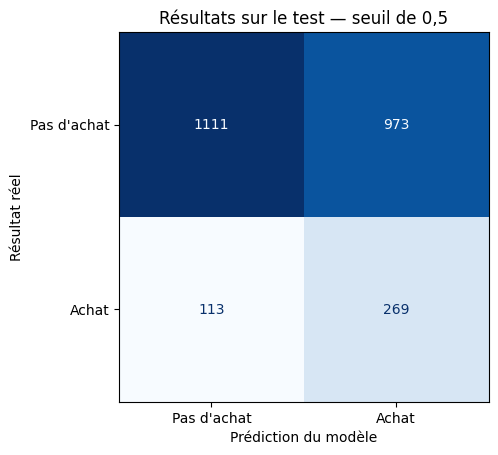

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions_test,
    labels=[False, True],
    display_labels=["Pas d'achat", "Achat"],
    cmap="Blues",
    colorbar=False
)

plt.title("Résultats sur le test — seuil de 0,5")
plt.xlabel("Prédiction du modèle")
plt.ylabel("Résultat réel")
plt.show()